### Problématique : 

Comment prédire si une machine industrielle risque de tomber en panne à partir de données capteurs afin d’anticiper une intervention de maintenance ?

### Chargement de la dataset

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,
    classification_report,ConfusionMatrixDisplay)
df = pd.read_csv("predictive_maintenance.csv")

print("Dimensions du dataset :", df.shape)
display(df.head())


Dimensions du dataset : (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


explication :
- Target = 0 → pas de panne
- Target = 1 → panne machine

### information sur la dataset

In [62]:

print("\nStatistiques descriptives :")
display(df.describe())
print("\nNombre de doublons :", df.duplicated().sum())


Statistiques descriptives :


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000



Nombre de doublons : 0


### Vérifier les valeurs manquantes

In [9]:
missing_values = df.isna().sum().sort_values(ascending=False)

display(missing_values)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

### Identifier la cible

In [10]:
target_col = "Target"

print("Répartition de la cible :")
display(df[target_col].value_counts())

print("Répartition en pourcentage :")
display(df[target_col].value_counts(normalize=True) * 100)

Répartition de la cible :


Target
0    9661
1     339
Name: count, dtype: int64

Répartition en pourcentage :


Target
0    96.61
1     3.39
Name: proportion, dtype: float64

### Visualiser la distribution de la cible

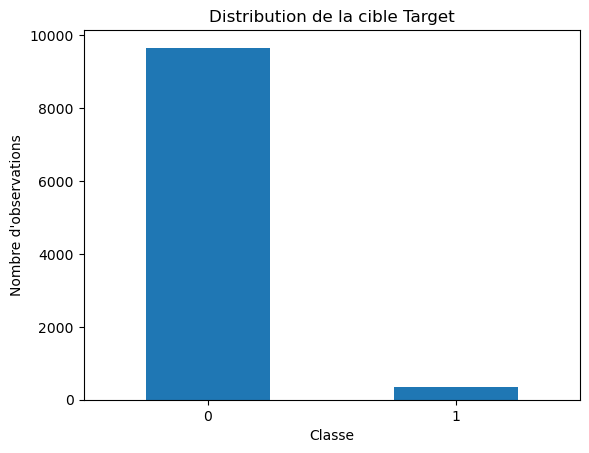

In [11]:
df[target_col].value_counts().plot(kind="bar")
plt.title("Distribution de la cible Target")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.show()

### Supprimer les colonnes inutiles

In [12]:
colonnes_a_supprimer = ["UDI", "Product ID", "Failure Type"]

df_clean = df.drop(columns=colonnes_a_supprimer)

print("Colonnes supprimées :", colonnes_a_supprimer)
print("Dimensions après nettoyage :", df_clean.shape)
display(df_clean.head())

Colonnes supprimées : ['UDI', 'Product ID', 'Failure Type']
Dimensions après nettoyage : (10000, 7)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


### Créer une fonction de feature engineering

In [14]:
def ajouter_features(data):
    data = data.copy()
    
    data["temperature_diff"] = (
        data["Process temperature [K]"] - data["Air temperature [K]"]
    )
    
    data["power_estimate"] = (
        data["Torque [Nm]"] * data["Rotational speed [rpm]"]
    )
    
    data["wear_level"] = pd.cut(
        data["Tool wear [min]"],
        bins=[-1, 50, 150, np.inf],
        labels=["faible", "moyenne", "forte"]
    )
    
    return data
df_features = ajouter_features(df_clean)

print("Dimensions après feature engineering :", df_features.shape)
display(df_features.head())

Dimensions après feature engineering : (10000, 10)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,temperature_diff,power_estimate,wear_level
0,M,298.1,308.6,1551,42.8,0,0,10.5,66382.8,faible
1,L,298.2,308.7,1408,46.3,3,0,10.5,65190.4,faible
2,L,298.1,308.5,1498,49.4,5,0,10.4,74001.2,faible
3,L,298.2,308.6,1433,39.5,7,0,10.4,56603.5,faible
4,L,298.2,308.7,1408,40.0,9,0,10.5,56320.0,faible


### Séparer X et y

In [17]:
X = df_features.drop(columns=[target_col])
y = df_features[target_col]
print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)

Dimensions X : (10000, 9)
Dimensions y : (10000,)


### Identifier variables numériques et catégorielles

In [18]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numériques :")
print(numeric_features)

print("\nVariables catégorielles :")
print(categorical_features)

Variables numériques :
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temperature_diff', 'power_estimate']

Variables catégorielles :
['Type', 'wear_level']


### Split train/test

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

print("\nRépartition train :")
display(y_train.value_counts(normalize=True) * 100)

print("\nRépartition test :")
display(y_test.value_counts(normalize=True) * 100)

Train : (8000, 9)
Test : (2000, 9)

Répartition train :


Target
0    96.6125
1     3.3875
Name: proportion, dtype: float64


Répartition test :


Target
0    96.6
1     3.4
Name: proportion, dtype: float64

### Créer le preprocessing

In [64]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
print("Variables numériques :", numeric_features)
print("Variables catégorielles :", categorical_features)

preprocessor


Variables numériques : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temperature_diff', 'power_estimate']
Variables catégorielles : ['Type', 'wear_level']


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Créer une baseline

In [45]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

baseline_resultats = pd.DataFrame([{
    "modele": "Baseline DummyClassifier",
    "accuracy": accuracy_score(y_test, y_pred_baseline),
    "precision": precision_score(y_test, y_pred_baseline, zero_division=0),
    "recall": recall_score(y_test, y_pred_baseline, zero_division=0),
    "f1": f1_score(y_test, y_pred_baseline, zero_division=0)
}])

display(baseline_resultats)

,modele,accuracy,precision,recall,f1
0,Baseline DummyClassifier,0.966,0.0,0.0,0.0


### Arène avec au moins 3 algorithmes

#### Modèles candidats avec résultat visible

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

modeles = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

modeles_df = pd.DataFrame({
    "Nom du modèle": list(modeles.keys()),
    "Algorithme utilisé": [type(modele).__name__ for modele in modeles.values()]
})
print("Nombre de modèles candidats :", len(modeles))
display(modeles_df)



Nombre de modèles candidats : 4


,Nom du modèle,Algorithme utilisé
0,Logistic Regression,LogisticRegression
1,Random Forest,RandomForestClassifier
2,Gradient Boosting,GradientBoostingClassifier
3,SVM,SVC


### Fonction d’évaluation

In [52]:
import time
from sklearn.metrics import roc_auc_score

def evaluer_modeles(modeles, preprocessor, X_train, X_test, y_train, y_test):
    resultats = []
    
    for nom_modele, modele in modeles.items():
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", modele)
        ])
        
        debut = time.time()
        pipeline.fit(X_train, y_train)
        temps = time.time() - debut
        
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        resultats.append({
            "modele": nom_modele,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
            "temps_entrainement_sec": temps,
            "pipeline": pipeline
        })
    
    return pd.DataFrame(resultats)

leaderboard = evaluer_modeles(modeles=modeles,preprocessor=preprocessor,X_train=X_train,X_test=X_test,
    y_train=y_train,y_test=y_test)

leaderboard_affichage = leaderboard.drop(columns=["pipeline"]).sort_values(
    by="f1",
    ascending=False)

display(leaderboard_affichage)


,modele,accuracy,precision,recall,f1,roc_auc,temps_entrainement_sec
2,Gradient Boosting,0.9910,0.946429,0.779412,0.854839,0.975913,1.119581
1,Random Forest,0.9875,0.938776,0.676471,0.786325,0.965195,1.097030
3,SVM,0.9235,0.294686,0.897059,0.443636,0.967650,2.313291
0,Logistic Regression,0.8655,0.188854,0.897059,0.312020,0.931761,0.036403


### Lancer l’Arène des algorithmes

In [25]:
leaderboard = evaluer_modeles(
    modeles=modeles,
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

leaderboard_affichage = leaderboard.drop(columns=["pipeline"]).sort_values(
    by="f1",
    ascending=False
)

display(leaderboard_affichage)

,modele,accuracy,precision,recall,f1,roc_auc,temps_entrainement_sec
2,Gradient Boosting,0.9910,0.946429,0.779412,0.854839,0.975913,2.279660
1,Random Forest,0.9875,0.938776,0.676471,0.786325,0.965195,2.189672
3,SVM,0.9235,0.294686,0.897059,0.443636,0.967650,5.505209
0,Logistic Regression,0.8655,0.188854,0.897059,0.312020,0.931761,0.103139


### Sauvegarder le leaderboard

In [27]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = NOTEBOOK_DIR

LEADERBOARD_PATH = PROJECT_DIR / "leaderboard.csv"

print("Chemin leaderboard :", LEADERBOARD_PATH)

leaderboard_affichage.to_csv(LEADERBOARD_PATH, index=False)

print("Leaderboard sauvegardé ici :", LEADERBOARD_PATH)

Chemin leaderboard : C:\Users\houda\Projet 5\leaderboard.csv
Leaderboard sauvegardé ici : C:\Users\houda\Projet 5\leaderboard.csv


### Choisir le champion

In [54]:
meilleure_ligne = leaderboard.sort_values(by="f1", ascending=False).iloc[0]

nom_champion = meilleure_ligne["modele"]
champion = meilleure_ligne["pipeline"]

print("Champion sélectionné :", nom_champion)
print("Accuracy :", meilleure_ligne["accuracy"])
print("Precision :", meilleure_ligne["precision"])
print("Recall :", meilleure_ligne["recall"])
print("F1-score :", meilleure_ligne["f1"])
print("ROC-AUC :", meilleure_ligne["roc_auc"])

Champion sélectionné : Gradient Boosting
Accuracy : 0.991
Precision : 0.9464285714285714
Recall : 0.7794117647058824
F1-score : 0.8548387096774194
ROC-AUC : 0.9759126476677629


#### Rapport détaillé du champion

In [55]:
y_pred_champion = champion.predict(X_test)

print("Rapport de classification du champion :")
print(classification_report(y_test, y_pred_champion, zero_division=0))

Rapport de classification du champion :
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.97      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000



justification
- Le champion retenu est le Gradient Boosting Il obtient le meilleur F1-score du leaderboard.  
Ce choix est cohérent avec le problème métier : la classe panne est minoritaire, donc nous ne nous basons pas uniquement sur l’accuracy.  
Le F1-score permet d’équilibrer la precision et le recall,Le recall reste important car rater une panne peut entraîner un arrêt de production non anticipé.Le Gradient Boosting offre ici le meilleur compromis entre détection des pannes et limitation des fausses alertes.

### Matrice de confusion

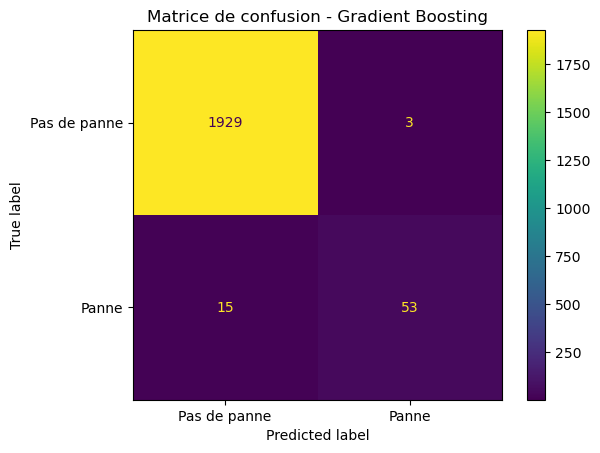

In [30]:
cm = confusion_matrix(y_test, y_pred_champion)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Pas de panne", "Panne"]
)

disp.plot()
plt.title(f"Matrice de confusion - {nom_champion}")
plt.show()

### Validation croisée

In [56]:
from sklearn.model_selection import cross_val_score

scores_cv = cross_val_score(
    champion,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Scores F1 en validation croisée :", scores_cv)
print("F1 moyen :", scores_cv.mean())
print("Écart-type :", scores_cv.std())

Scores F1 en validation croisée : [0.65306122 0.6        0.31090487 0.79365079 0.71559633]
F1 moyen : 0.614642644161122
Écart-type : 0.16503490095543755


interprétation
- La validation croisée donne un F1 moyen inférieur au score obtenu sur le split test.  
Cela montre que le modèle reste sensible au découpage des données, probablement à cause du fort déséquilibre de la classe panne.  
Cependant, le score reste supérieur à la baseline, dont le F1-score est égal à 0.  


### courbe ROC

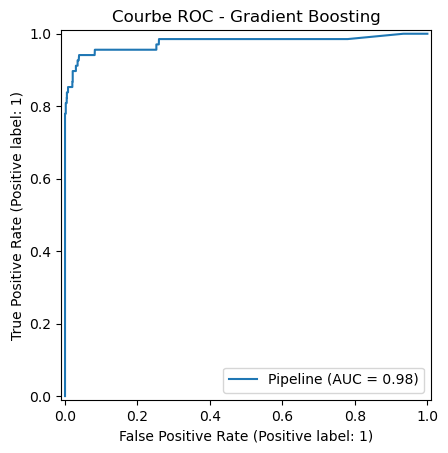

In [66]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(champion, X_test, y_test)
plt.title(f"Courbe ROC - {nom_champion}")
plt.show()

### courbe Precision-Recall

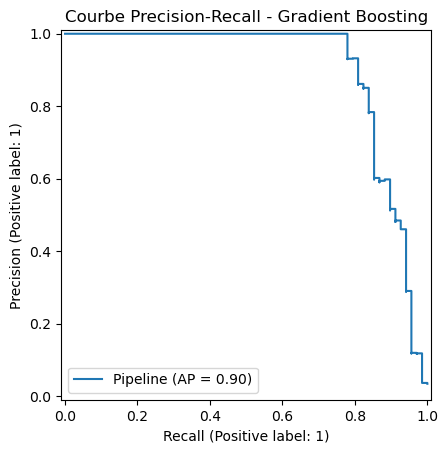

In [67]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(champion, X_test, y_test)
plt.title(f"Courbe Precision-Recall - {nom_champion}")
plt.show()

### Créer la fonction de sauvegarde

In [32]:
def sauvegarder_champion(champion, chemin):
    joblib.dump(champion, chemin)
    return chemin

### Sauvegarder le champion

In [35]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = NOTEBOOK_DIR

MODEL_PATH = PROJECT_DIR / "champion.joblib"

chemin_sauvegarde = sauvegarder_champion(champion, MODEL_PATH)

print("Champion sauvegardé ici :", chemin_sauvegarde)
print("Fichier créé :", MODEL_PATH.exists())

Champion sauvegardé ici : C:\Users\houda\Projet 5\champion.joblib
Fichier créé : True
